In [1]:
import matplotlib

matplotlib.rcParams.update({"legend.fontsize": 14, "legend.handlelength": 2})
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.5)
import pandas as pd

#### Load `uam_system_model` dependencies

In [4]:
from uam_system_model.StarNetwork import StarNetwork
from uam_system_model.FleetOpVRP import FleetOpVRP
from uam_system_model.utils.visualize import (
    plot_hourly_flight_distribution,
    plot_parameters,
)

#### Prepare input

In [5]:
def calculate_distances_in_meters(coords):
    num_points = len(coords)
    distance_matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        for j in range(num_points):
            if i != j:
                distance_matrix[i][j] = geodesic(coords[i], coords[j]).meters / 1600
    return distance_matrix


import numpy as np
from geopy.distance import geodesic

coordinates = np.array(
    [
        (33.94417072663332, -118.40248449470265),
        (34.043119432990345, -118.26720629762752),
        (33.81606030845284, -118.15122129260827),
        (34.17160155814583, -118.60525790222589),
        (34.13843197335217, -118.35511311047983),
        (33.812102161009804, -117.91897753216998),
        (34.09174681098575, -118.32725521957076),
        (34.08807589928915, -118.55063573741867),
        (34.06666969690935, -118.4114352069469),
    ]
)

distance_matrix = calculate_distances_in_meters(coordinates)
vertiports = ["LAX", "DTLA", "LGB", "WDHL", "UVS", "ANH", "HWD", "PSD", "BVH"]

vertiport_pmf = np.array([0, 6.1, 3.3, 1.5, 1.5, 5.4, 4.3, 2.5, 2.2])
vertiport_pmf = vertiport_pmf / vertiport_pmf.sum()

flight_time_matrix = np.load("uam_system_model/data/config/flight_time_matrix.npy")
energy_consumption_matrix = np.load(
    "uam_system_model/data/config/energy_consumption_matrix.npy"
)

#### Create instance variable

In [6]:
network = StarNetwork(
    vertiport_names=vertiports,
    flight_distance_matrix=distance_matrix,
    flight_time_matrix=flight_time_matrix,
    energy_consumption_matrix=energy_consumption_matrix,
)

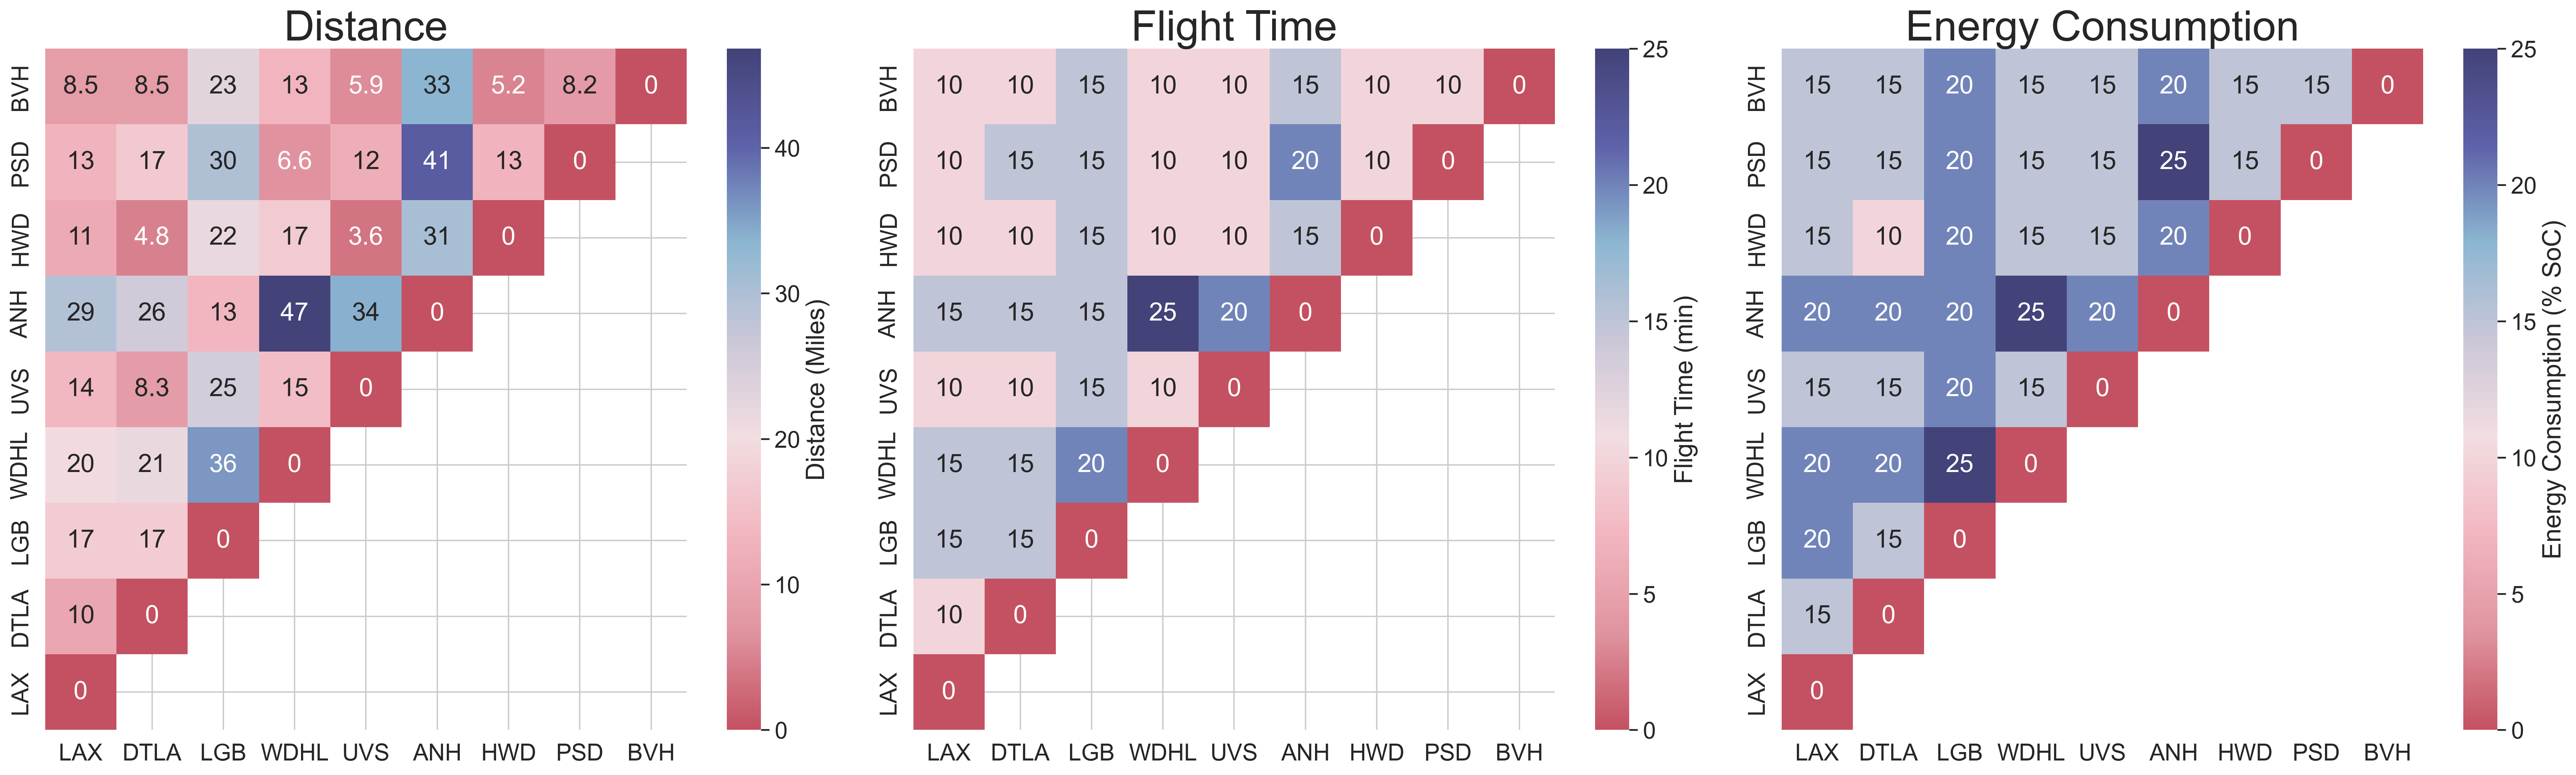

In [7]:
plot_parameters(network);

#### Load demand & visualize

In [10]:
network.load_demand(
    month=8,
    day=1,
    directional_demand=300,
    vertiport_pmf=vertiport_pmf,
)
network.schedule

,schedule,od,num_pax,revenue
0,5.000000,LAX_BVH,1,25.524422
1,5.569175,LAX_ANH,1,88.256047
2,11.810999,LAX_HWD,1,33.343620
3,17.259829,LAX_HWD,1,33.343620
4,28.823542,LAX_ANH,1,88.256047
...,...,...,...,...
578,1437.817750,LAX_LGB,1,51.083877
579,1437.841763,LAX_DTLA,1,31.188102
580,1439.658701,UVS_LAX,1,41.226701
581,1439.962714,LAX_LGB,1,51.083877


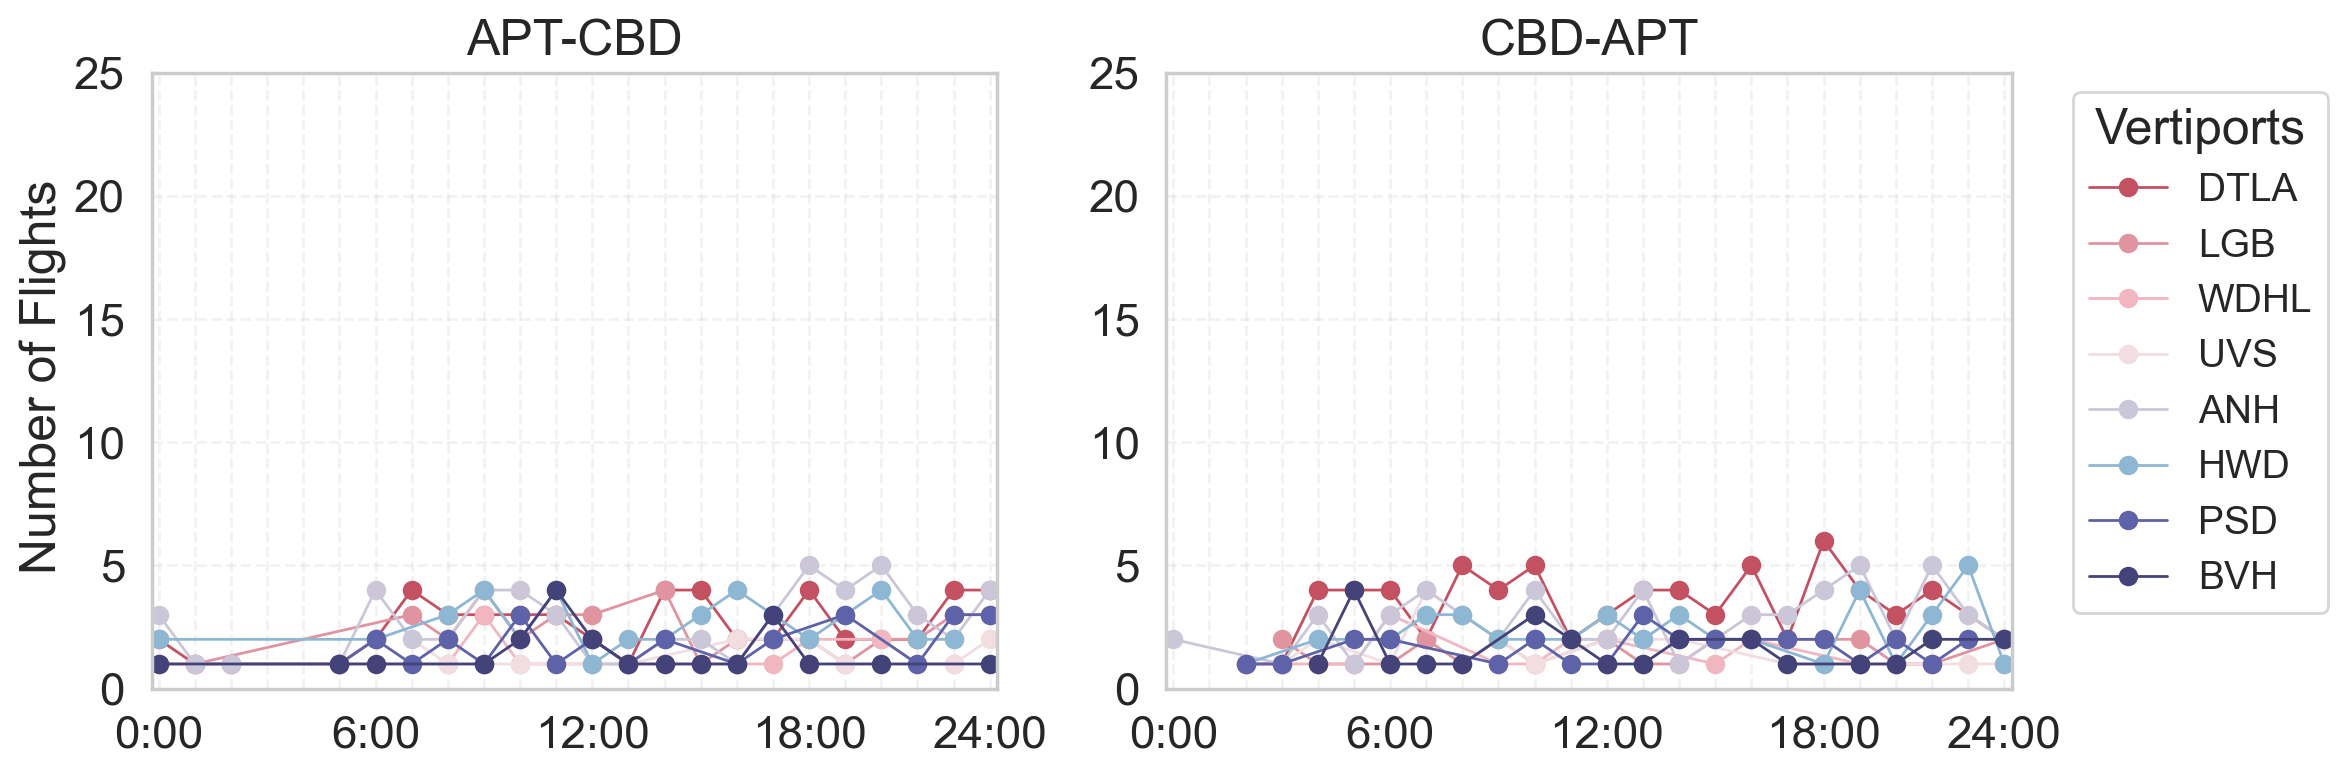

In [9]:
fig, ax = plot_hourly_flight_distribution(network, ylim=(0, 25))
plt.show()

#### Run VRP Optimization

In [11]:
vrp = FleetOpVRP(StarNetwork=network)
unserved_tours, served_tours = vrp.optimize(15, 3, 0.7, n_processes=20, verbose=True)

INFO - 2025-07-08 17:05:38,225 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [1] BUILDING SUBTOURS
INFO - 2025-07-08 17:05:51,079 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [2] SOLVING KNAPSACK PROBLEM


Set parameter Username
Set parameter LicenseID to value 2674870
Academic license - for non-commercial use only - expires 2026-06-04


INFO - 2025-07-08 17:06:04,994 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - NUMBER OF FLIGHTS BEFORE: 583 NUMBER OF TOURS AFTER: 583
INFO - 2025-07-08 17:06:04,995 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [3] SOLVING THE CLUSTERING/SCHEDULING PROBLEM
100%|██████████| 1168/1168 [00:28<00:00, 41.33it/s]
INFO - 2025-07-08 17:06:41,034 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - NUMBER OF FLIGHTS SELECTED AFTER CLUSTERING: 583/583
INFO - 2025-07-08 17:06:41,036 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [4] SOLVING 1-VRP


TOURS SERVED: 30/35
FLIGHTS SERVED: 30/35
TOURS SERVED: 35/40
FLIGHTS SERVED: 35/40
TOURS SERVED: 34/38
FLIGHTS SERVED: 34/38
TOURS SERVED: 31/37
FLIGHTS SERVED: 31/37
TOURS SERVED: 27/38
FLIGHTS SERVED: 27/38
TOURS SERVED: 30/36TOURS SERVED: 28/37
FLIGHTS SERVED: 28/37

FLIGHTS SERVED: 30/36
TOURS SERVED: 30/35
FLIGHTS SERVED: 30/35
TOURS SERVED: 30/42
FLIGHTS SERVED: 30/42
TOURS SERVED: 34/42TOURS SERVED: 31/40
FLIGHTS SERVED: 31/40

FLIGHTS SERVED: 34/42
TOURS SERVED: 28/39
FLIGHTS SERVED: 28/39
TOURS SERVED: 36/41
FLIGHTS SERVED: 36/41
TOURS SERVED: 28/40
FLIGHTS SERVED: 28/40
TOURS SERVED: 30/43
FLIGHTS SERVED: 30/43


INFO - 2025-07-08 17:37:05,051 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - NUMBER OF SERVED FLIGHTS: 462 / 583
INFO - 2025-07-08 17:37:05,052 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [5] Iterative Insertion


TOURS SERVED: 35/130
FLIGHTS SERVED: 35/130
TOURS SERVED: 38/129
FLIGHTS SERVED: 38/129
TOURS SERVED: 32/122
FLIGHTS SERVED: 32/122
TOURS SERVED: 34/117
FLIGHTS SERVED: 34/117
TOURS SERVED: 34/117
FLIGHTS SERVED: 34/117
TOURS SERVED: 36/113
FLIGHTS SERVED: 36/113
TOURS SERVED: 35/108
FLIGHTS SERVED: 35/108
TOURS SERVED: 37/109
FLIGHTS SERVED: 37/109
TOURS SERVED: 40/107
FLIGHTS SERVED: 40/107
TOURS SERVED: 33/95
FLIGHTS SERVED: 33/95
TOURS SERVED: 34/90
FLIGHTS SERVED: 34/90
TOURS SERVED: 32/84
FLIGHTS SERVED: 32/84
TOURS SERVED: 31/82
FLIGHTS SERVED: 31/82
TOURS SERVED: 32/81
FLIGHTS SERVED: 32/81


INFO - 2025-07-08 17:44:21,317 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - OPTIMIZATION COMPLETE
INFO - 2025-07-08 17:44:21,318 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - TOTAL NUMBER OF SERVED FLIGHTS: 517. SERVED RATIO: 0.8867924528301887
INFO - 2025-07-08 17:44:21,319 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - Total time taken: 38.71865012645721 minutes


TOURS SERVED: 34/79
FLIGHTS SERVED: 34/79
